In [1]:
# ==========================================================
# CELL 1
# Import all required libraries
# ==========================================================

print("Starting cell #1")

import os
import gc
import random
import math
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils import clip_grad_norm_

from transformers import (
    AutoTokenizer,
    XLMRobertaModel,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("Executed cell #1")

Starting cell #1
Executed cell #1


In [2]:
# ==========================================================
# CELL 2
# Set Kaggle dataset file names and dataset discovery hint
# ==========================================================

print("Starting cell #2")

TRAIN_FILE_NAME = "train.csv"
VALIDATION_FILE_NAME = "validation.csv"
TEST_FILE_NAME = "test.csv"

KAGGLE_INPUT_ROOT = "/kaggle/input"
DATASET_FOLDER_HINT = "Dataset"

print("Train file name:", TRAIN_FILE_NAME)
print("Validation file name:", VALIDATION_FILE_NAME)
print("Test file name:", TEST_FILE_NAME)
print("Executed cell #2")

Starting cell #2
Train file name: train.csv
Validation file name: validation.csv
Test file name: test.csv
Executed cell #2


In [3]:
# ==========================================================
# CELL 3
# Fast accuracy-tuned baseline settings
# Core method remains unchanged:
# 12-layer XLM-R + parallel-row training + flat evaluation
# CE + row alignment + supervised contrastive loss
# No KD and no student compression.
# ==========================================================

print("Starting cell #3")

# -----------------------------
# Backbone
# -----------------------------
BASELINE_MODEL_NAME = "xlm-roberta-base"

# -----------------------------
# Dataset columns after normalize_columns()
# Original CSV columns: Label, Bengali, Banglish, English
# Normalized columns: label, bengali, banglish, english
# -----------------------------
LABEL_COLUMN = "label"
BANGLA_COLUMN = "bengali"
BANGLISH_COLUMN = "banglish"
ENGLISH_COLUMN = "english"

LANGUAGE_COLUMNS = [
    (BANGLA_COLUMN, "bengali"),
    (BANGLISH_COLUMN, "banglish"),
    (ENGLISH_COLUMN, "english")
]

NUM_LANGUAGES = 3

# -----------------------------
# Fast training setup
# This keeps the baseline method unchanged but reduces runtime strongly.
# Main speed changes:
# 1. One combined XLM-R forward pass for Bangla+Banglish+English instead of 3 separate forward passes.
# 2. MAX_LENGTH reduced from 160 to 128.
# 3. Gradient checkpointing disabled for speed.
# 4. Larger triplet batch size and no gradient accumulation by default.
# 5. Heavy full checkpoint saved once at the end, not after every validation improvement.
# -----------------------------
SEED = 42

MAX_LENGTH = 128
BASELINE_EPOCHS = 8

# One triplet batch contains TRAIN_BATCH_SIZE original rows.
# The model sees 3 * TRAIN_BATCH_SIZE sentences in one combined forward pass.
# If Kaggle gives CUDA OOM, set TRAIN_BATCH_SIZE = 12.
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 128
GRADIENT_ACCUMULATION_STEPS = 1
GRAD_CLIP = 1.0

WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
LABEL_SMOOTHING = 0.02
MODEL_DROPOUT = 0.10

BASELINE_ENCODER_LR = 2e-5
BASELINE_HEAD_LR = 1e-4

# -----------------------------
# Contrastive losses
# Core baseline loss unchanged.
# -----------------------------
ROW_ALIGN_TEMPERATURE = 0.07
SUPCON_TEMPERATURE = 0.07
ROW_ALIGN_WEIGHT = 0.05
SUPCON_WEIGHT = 0.03

# Balanced sampler remains available but is not used in this fast baseline.
# Full row coverage is used every epoch for fair comparison and stable accuracy.
CLASSES_PER_BATCH = 6
SAMPLES_PER_CLASS = 3
BALANCED_BATCH_SIZE = CLASSES_PER_BATCH * SAMPLES_PER_CLASS

CHECKPOINT_MONITOR = "accuracy"   # options: accuracy, macro_f1, weighted_f1
EARLY_STOPPING_PATIENCE = 3

# Gradient checkpointing reduces memory but often makes training much slower.
# Keep False for speed. If CUDA OOM happens, use TRAIN_BATCH_SIZE = 8 or set this True.
ENABLE_GRADIENT_CHECKPOINTING = False

# Save directory. No CSV files are created.
SAVE_DIR = "/kaggle/working/baseline_12layer_xlmr_fast_training"
os.makedirs(SAVE_DIR, exist_ok=True)

baseline_model_only_path = os.path.join(SAVE_DIR, "best_baseline_12layer_model_only.pt")
baseline_full_checkpoint_path = os.path.join(SAVE_DIR, "baseline_12layer_full_training_checkpoint.pt")

print("Baseline model:", BASELINE_MODEL_NAME)
print("Training strategy: full 12-layer XLM-R + CE + row alignment + SupCon")
print("No KD and no student compression in this baseline.")
print("MAX_LENGTH:", MAX_LENGTH)
print("Epochs:", BASELINE_EPOCHS)
print("Triplet batch size, original rows:", TRAIN_BATCH_SIZE)
print("Sentences per model forward:", TRAIN_BATCH_SIZE * 3)
print("Gradient accumulation steps:", GRADIENT_ACCUMULATION_STEPS)
print("Loss weights: CE +", ROW_ALIGN_WEIGHT, "* row alignment +", SUPCON_WEIGHT, "* SupCon")
print("Checkpoint monitor:", CHECKPOINT_MONITOR)
print("Model-only checkpoint path:", baseline_model_only_path)
print("Full training checkpoint path:", baseline_full_checkpoint_path)
print("Executed cell #3")

Starting cell #3
Baseline model: xlm-roberta-base
Training strategy: full 12-layer XLM-R + CE + row alignment + SupCon
No KD and no student compression in this baseline.
MAX_LENGTH: 128
Epochs: 8
Triplet batch size, original rows: 16
Sentences per model forward: 48
Gradient accumulation steps: 1
Loss weights: CE + 0.05 * row alignment + 0.03 * SupCon
Checkpoint monitor: accuracy
Model-only checkpoint path: /kaggle/working/baseline_12layer_xlmr_fast_training/best_baseline_12layer_model_only.pt
Full training checkpoint path: /kaggle/working/baseline_12layer_xlmr_fast_training/baseline_12layer_full_training_checkpoint.pt
Executed cell #3


In [4]:
# ==========================================================
# CELL 4
# Set random seeds for reproducibility
# ==========================================================

print("Starting cell #4")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

print("Seed:", SEED)
print("Executed cell #4")

Starting cell #4
Seed: 42
Executed cell #4


In [5]:
# ==========================================================
# CELL 5
# Check GPU and configure AMP
# ==========================================================

print("Starting cell #5")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = torch.cuda.is_available()

print("Device:", device)

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))

print("AMP enabled:", AMP_ENABLED)
print("Executed cell #5")

Starting cell #5
Device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
AMP enabled: True
Executed cell #5


In [6]:
# ==========================================================
# CELL 6
# Resolve train, validation, and test CSV paths
# ==========================================================

print("Starting cell #6")

def find_file_in_kaggle(filename, root=KAGGLE_INPUT_ROOT):
    matches = []
    for dirpath, dirnames, filenames in os.walk(root):
        if filename in filenames:
            matches.append(os.path.join(dirpath, filename))

    if len(matches) == 0:
        raise FileNotFoundError(f"Could not find {filename} under {root}")

    preferred = [m for m in matches if DATASET_FOLDER_HINT.lower() in m.lower()]
    if preferred:
        return preferred[0]

    return matches[0]

train_path = find_file_in_kaggle(TRAIN_FILE_NAME)
validation_path = find_file_in_kaggle(VALIDATION_FILE_NAME)
test_path = find_file_in_kaggle(TEST_FILE_NAME)

print("Train path:", train_path)
print("Validation path:", validation_path)
print("Test path:", test_path)
print("Executed cell #6")

Starting cell #6
Train path: /kaggle/input/datasets/sajidruetcse21/dataset/train.csv
Validation path: /kaggle/input/datasets/sajidruetcse21/dataset/validation.csv
Test path: /kaggle/input/datasets/sajidruetcse21/dataset/test.csv
Executed cell #6


In [7]:
# ==========================================================
# CELL 7
# Load datasets and normalize column names
# ==========================================================

print("Starting cell #7")

def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_csv(path):
    return normalize_columns(pd.read_csv(path))

train_df = load_csv(train_path)
val_df = load_csv(validation_path)
test_df = load_csv(test_path)

required_columns = [LABEL_COLUMN, BANGLA_COLUMN, BANGLISH_COLUMN, ENGLISH_COLUMN]

for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {split_name}.csv: {missing}")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Columns:", train_df.columns.tolist())
print("\nPreview:")
print(train_df.head().to_string(index=False))
print("Executed cell #7")

Starting cell #7
Train shape: (56067, 4)
Validation shape: (7929, 4)
Test shape: (16101, 4)
Columns: ['label', 'bengali', 'banglish', 'english']

Preview:
  label                                                                                                                                                                                     bengali                                                                                                                                                                                                   banglish                                                                                                                                                                                       english
  anger                                                                                               মিন্নী যে জঘন্য কাজ করার পরও যদি জামিন পায়।তাহলে এই দেশের সকল ফাসি আসামিদের জামিন দিতে হবে।।।                                                             

In [8]:
# ==========================================================
# CELL 8
# Encode emotion labels and build class weights
# ==========================================================

print("Starting cell #8")

label_encoder = LabelEncoder()
label_encoder.fit(train_df[LABEL_COLUMN].astype(str))

train_df["label_id"] = label_encoder.transform(train_df[LABEL_COLUMN].astype(str))
val_df["label_id"] = label_encoder.transform(val_df[LABEL_COLUMN].astype(str))
test_df["label_id"] = label_encoder.transform(test_df[LABEL_COLUMN].astype(str))

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}
NUM_LABELS = len(label_encoder.classes_)
target_names = [id2label[i] for i in range(NUM_LABELS)]

print("Emotion classes:")
for i, label in id2label.items():
    print(i, "->", label)

class_counts = train_df["label_id"].value_counts().sort_index()
print("\nOriginal-row class counts:")
for i in range(NUM_LABELS):
    print(id2label[i], ":", int(class_counts.get(i, 0)))

# Same weight calculation as the proposed notebook.
total_samples = len(train_df)
class_weights = []
for class_id in range(NUM_LABELS):
    count = class_counts.get(class_id, 1)
    class_weights.append(total_samples / (NUM_LABELS * count))

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("\nClass weights:")
for i, w in enumerate(class_weights.tolist()):
    print(id2label[i], ":", round(w, 4))

print("Executed cell #8")

Starting cell #8
Emotion classes:
0 -> anger
1 -> disgust
2 -> fear
3 -> joy
4 -> sadness
5 -> surprise

Original-row class counts:
anger : 10626
disgust : 9169
fear : 5295
joy : 12486
sadness : 11416
surprise : 7075

Class weights:
anger : 0.8794
disgust : 1.0191
fear : 1.7648
joy : 0.7484
sadness : 0.8185
surprise : 1.3208
Executed cell #8


In [9]:
# ==========================================================
# CELL 9
# Build flat classification dataframe and triplet dataframe
# ==========================================================

print("Starting cell #9")

def clean_text_value(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def build_flat_dataframe(df):
    rows = []

    for row_id, row in df.reset_index(drop=True).iterrows():
        label_id = int(row["label_id"])

        for text_col, lang_name in LANGUAGE_COLUMNS:
            text = clean_text_value(row[text_col])
            if text:
                rows.append({
                    "source_row_id": row_id,
                    "text": text,
                    "label_id": label_id,
                    "language": lang_name
                })

    return pd.DataFrame(rows)


def build_triplet_dataframe(df):
    rows = []

    for row_id, row in df.reset_index(drop=True).iterrows():
        bangla = clean_text_value(row[BANGLA_COLUMN])
        banglish = clean_text_value(row[BANGLISH_COLUMN])
        english = clean_text_value(row[ENGLISH_COLUMN])

        if not (bangla and banglish and english):
            continue

        rows.append({
            "row_id": row_id,
            "bangla": bangla,
            "banglish": banglish,
            "english": english,
            "label_id": int(row["label_id"])
        })

    return pd.DataFrame(rows)

flat_train_df = build_flat_dataframe(train_df)
flat_val_df = build_flat_dataframe(val_df)
flat_test_df = build_flat_dataframe(test_df)

triplet_train_df = build_triplet_dataframe(train_df)
triplet_val_df = build_triplet_dataframe(val_df)
triplet_test_df = build_triplet_dataframe(test_df)

print("Flat train shape:", flat_train_df.shape)
print("Flat validation shape:", flat_val_df.shape)
print("Flat test shape:", flat_test_df.shape)
print("Triplet train shape:", triplet_train_df.shape)
print("Triplet validation shape:", triplet_val_df.shape)
print("Triplet test shape:", triplet_test_df.shape)

print("\nMeaning:")
print("One original row contributes three sentence-level samples for evaluation.")
print("During training, the three parallel sentences are processed together so row alignment can be computed.")

print("Executed cell #9")

Starting cell #9
Flat train shape: (168197, 4)
Flat validation shape: (23787, 4)
Flat test shape: (48301, 4)
Triplet train shape: (56063, 5)
Triplet validation shape: (7929, 5)
Triplet test shape: (16099, 5)

Meaning:
One original row contributes three sentence-level samples for evaluation.
During training, the three parallel sentences are processed together so row alignment can be computed.
Executed cell #9


In [10]:
# ==========================================================
# CELL 10
# Load tokenizer
# ==========================================================

print("Starting cell #10")

tokenizer = AutoTokenizer.from_pretrained(BASELINE_MODEL_NAME)

print("Tokenizer vocab size:", tokenizer.vocab_size)
print("Executed cell #10")

Starting cell #10


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer vocab size: 250002
Executed cell #10


In [11]:
# ==========================================================
# CELL 11
# Define flat and triplet datasets
# ==========================================================

print("Starting cell #11")

class FlatEmotionDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "text": row["text"],
            "labels": int(row["label_id"]),
            "language": row["language"]
        }


class TripletEmotionDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "bangla": row["bangla"],
            "banglish": row["banglish"],
            "english": row["english"],
            "labels": int(row["label_id"]),
            "row_id": int(row["row_id"])
        }

print("Executed cell #11")

Starting cell #11
Executed cell #11


In [12]:
# ==========================================================
# CELL 12
# Define dynamic padding collators
# Fast triplet collator tokenizes Bangla+Banglish+English together.
# This allows one combined XLM-R forward pass per batch instead of three.
# ==========================================================

print("Starting cell #12")

class FlatCollator:
    def __init__(self, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, batch):
        texts = [item["text"] for item in batch]
        labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)

        encoded = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        encoded["labels"] = labels
        return encoded


class TripletCollator:
    def __init__(self, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, batch):
        bangla_texts = [item["bangla"] for item in batch]
        banglish_texts = [item["banglish"] for item in batch]
        english_texts = [item["english"] for item in batch]

        # Language-major order is important:
        # [all Bangla, all Banglish, all English]
        # labels.repeat(3) matches this order.
        all_texts = bangla_texts + banglish_texts + english_texts

        labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)
        row_ids = torch.tensor([item["row_id"] for item in batch], dtype=torch.long)

        encoded = self.tokenizer(
            all_texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
            "labels": labels,
            "row_ids": row_ids,
            "triplet_batch_size": len(batch)
        }

flat_collator = FlatCollator(tokenizer, MAX_LENGTH)
triplet_collator = TripletCollator(tokenizer, MAX_LENGTH)

print("Fast triplet collator ready: one tokenization call and one model forward for 3 languages.")
print("Executed cell #12")

Starting cell #12
Fast triplet collator ready: one tokenization call and one model forward for 3 languages.
Executed cell #12


In [13]:
# ==========================================================
# CELL 13
# Define balanced class batch sampler for SupCon
# ==========================================================

print("Starting cell #13")

class BalancedClassBatchSampler(Sampler):
    def __init__(self, labels, classes_per_batch, samples_per_class, num_batches=None, seed=42):
        self.labels = np.array(labels)
        self.classes_per_batch = int(classes_per_batch)
        self.samples_per_class = int(samples_per_class)
        self.batch_size = self.classes_per_batch * self.samples_per_class
        self.seed = int(seed)

        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(self.labels):
            self.class_to_indices[int(label)].append(idx)

        self.classes = sorted(list(self.class_to_indices.keys()))

        if self.classes_per_batch > len(self.classes):
            raise ValueError("classes_per_batch cannot exceed number of classes")

        self.num_batches = math.ceil(len(self.labels) / self.batch_size) if num_batches is None else int(num_batches)

    def __len__(self):
        return self.num_batches

    def __iter__(self):
        rng = np.random.default_rng(self.seed + random.randint(0, 10_000_000))

        for _ in range(self.num_batches):
            selected_classes = rng.choice(self.classes, size=self.classes_per_batch, replace=False)
            batch_indices = []

            for class_id in selected_classes:
                indices = self.class_to_indices[int(class_id)]
                replace_needed = len(indices) < self.samples_per_class
                chosen = rng.choice(indices, size=self.samples_per_class, replace=replace_needed)
                batch_indices.extend(chosen.tolist())

            rng.shuffle(batch_indices)
            yield batch_indices

print("Balanced batch size:", BALANCED_BATCH_SIZE)
print("Executed cell #13")

Starting cell #13
Balanced batch size: 18
Executed cell #13


In [14]:
# ==========================================================
# CELL 14
# Build dataset objects and dataloaders
# ==========================================================

print("Starting cell #14")

NUM_WORKERS = 4 if torch.cuda.is_available() else 0
PIN_MEMORY = torch.cuda.is_available()

flat_train_dataset = FlatEmotionDataset(flat_train_df)
flat_val_dataset = FlatEmotionDataset(flat_val_df)
flat_test_dataset = FlatEmotionDataset(flat_test_df)

triplet_train_dataset = TripletEmotionDataset(triplet_train_df)
triplet_val_dataset = TripletEmotionDataset(triplet_val_df)
triplet_test_dataset = TripletEmotionDataset(triplet_test_df)

flat_val_loader = DataLoader(
    flat_val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=flat_collator,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

flat_test_loader = DataLoader(
    flat_test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=flat_collator,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

# Full coverage triplet loader: every original row appears once per epoch.
triplet_train_full_loader = DataLoader(
    triplet_train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=triplet_collator,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

# Balanced triplet loader remains available, but the fast baseline uses full coverage only.
balanced_sampler = BalancedClassBatchSampler(
    labels=triplet_train_df["label_id"].tolist(),
    classes_per_batch=CLASSES_PER_BATCH,
    samples_per_class=SAMPLES_PER_CLASS,
    seed=SEED
)

triplet_train_balanced_loader = DataLoader(
    triplet_train_dataset,
    batch_sampler=balanced_sampler,
    collate_fn=triplet_collator,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

print("NUM_WORKERS:", NUM_WORKERS)
print("Validation flat batches:", len(flat_val_loader))
print("Test flat batches:", len(flat_test_loader))
print("Triplet full-coverage train batches:", len(triplet_train_full_loader))
print("Triplet balanced train batches:", len(triplet_train_balanced_loader))
print("Model forward calls per epoch now equal train batches, not train batches × 3.")
print("Executed cell #14")

Starting cell #14
NUM_WORKERS: 4
Validation flat batches: 186
Test flat batches: 378
Triplet full-coverage train batches: 3504
Triplet balanced train batches: 3115
Model forward calls per epoch now equal train batches, not train batches × 3.
Executed cell #14


In [15]:
# ==========================================================
# CELL 15
# Define mean pooling and 12-layer XLM-R emotion classifier
# ==========================================================

print("Starting cell #15")

def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


class XLMRBaselineEmotionModel(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.10, enable_gradient_checkpointing=True):
        super().__init__()
        self.encoder = XLMRobertaModel.from_pretrained(model_name, add_pooling_layer=False)

        if enable_gradient_checkpointing:
            self.encoder.gradient_checkpointing_enable()
            self.encoder.config.use_cache = False

        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        embeddings = mean_pooling(outputs.last_hidden_state, attention_mask)
        logits = self.classifier(self.dropout(embeddings))

        return {
            "embeddings": embeddings,
            "logits": logits
        }


def get_base_model(model):
    if isinstance(model, nn.DataParallel):
        return model.module
    return model


def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

print("Executed cell #15")

Starting cell #15
Executed cell #15


In [16]:
# ==========================================================
# CELL 16
# Initialize 12-layer baseline model
# ==========================================================

print("Starting cell #16")

baseline_model = XLMRBaselineEmotionModel(
    model_name=BASELINE_MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout=MODEL_DROPOUT,
    enable_gradient_checkpointing=ENABLE_GRADIENT_CHECKPOINTING
)

baseline_model.to(device)

if torch.cuda.device_count() > 1:
    print("Using DataParallel for baseline model.")
    baseline_model = nn.DataParallel(baseline_model)

total_params, trainable_params = count_parameters(baseline_model)

print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")
print("Dropout:", MODEL_DROPOUT)
print("Gradient checkpointing:", ENABLE_GRADIENT_CHECKPOINTING)
print("Executed cell #16")

Starting cell #16


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using DataParallel for baseline model.
Total parameters: 277,457,670
Trainable parameters: 277,457,670
Dropout: 0.1
Gradient checkpointing: False
Executed cell #16


In [17]:
# ==========================================================
# CELL 17
# Define weighted CE, row alignment, and supervised contrastive losses
# ==========================================================

print("Starting cell #17")

classification_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=LABEL_SMOOTHING
)


class MultiPositiveRowAlignmentLoss(nn.Module):
    """
    Positive pairs:
    Bangla_i, Banglish_i, and English_i from the same original row.
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, emb_bangla, emb_banglish, emb_english):
        embeddings = torch.cat([emb_bangla, emb_banglish, emb_english], dim=0)
        embeddings = F.normalize(embeddings.float(), p=2, dim=1)

        batch_size = emb_bangla.size(0)
        device_local = embeddings.device
        row_ids = torch.arange(batch_size, device=device_local).repeat(3)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(sim_matrix.size(0), dtype=torch.bool, device=device_local)
        positive_mask = (row_ids.unsqueeze(0) == row_ids.unsqueeze(1)) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        positive_mask_float = positive_mask.float()
        positive_count = positive_mask_float.sum(dim=1)
        valid_anchor_mask = positive_count > 0

        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_count.clamp(min=1.0)
        )

        return -mean_log_prob_pos[valid_anchor_mask].mean()


class SupervisedContrastiveLoss(nn.Module):
    """
    Positive pairs: embeddings with the same emotion label.
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings.float(), p=2, dim=1)
        labels = labels.contiguous().view(-1)

        device_local = embeddings.device
        n = embeddings.size(0)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(n, dtype=torch.bool, device=device_local)
        positive_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        positive_mask_float = positive_mask.float()
        positive_count = positive_mask_float.sum(dim=1)
        valid_anchor_mask = positive_count > 0

        if valid_anchor_mask.sum() == 0:
            return torch.tensor(0.0, device=device_local, requires_grad=True)

        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_count.clamp(min=1.0)
        )

        return -mean_log_prob_pos[valid_anchor_mask].mean()


row_alignment_criterion = MultiPositiveRowAlignmentLoss(temperature=ROW_ALIGN_TEMPERATURE)
supcon_criterion = SupervisedContrastiveLoss(temperature=SUPCON_TEMPERATURE)

print("Losses ready:")
print("CE +", ROW_ALIGN_WEIGHT, "* row alignment +", SUPCON_WEIGHT, "* SupCon")
print("Executed cell #17")

Starting cell #17
Losses ready:
CE + 0.05 * row alignment + 0.03 * SupCon
Executed cell #17


In [18]:
# ==========================================================
# CELL 18
# Define optimizer helper with separate encoder/head learning rates
# ==========================================================

print("Starting cell #18")

def build_optimizer(model, encoder_lr, head_lr):
    base_model = get_base_model(model)

    encoder_named_params = []
    head_named_params = []

    for name, param in base_model.named_parameters():
        if not param.requires_grad:
            continue

        if name.startswith("encoder."):
            encoder_named_params.append((name, param))
        else:
            head_named_params.append((name, param))

    no_decay_terms = ["bias", "LayerNorm.weight", "LayerNorm.bias"]

    def build_groups(named_params, lr):
        decay_params = []
        no_decay_params = []

        for name, param in named_params:
            if any(term in name for term in no_decay_terms):
                no_decay_params.append(param)
            else:
                decay_params.append(param)

        groups = []
        if decay_params:
            groups.append({"params": decay_params, "lr": lr, "weight_decay": WEIGHT_DECAY})
        if no_decay_params:
            groups.append({"params": no_decay_params, "lr": lr, "weight_decay": 0.0})

        return groups

    return AdamW(
        build_groups(encoder_named_params, encoder_lr) +
        build_groups(head_named_params, head_lr)
    )

print("Executed cell #18")

Starting cell #18
Executed cell #18


In [19]:
# ==========================================================
# CELL 19
# Define flat sentence-level evaluation function
# ==========================================================

print("Starting cell #19")

@torch.inference_mode()
def evaluate_model(model, data_loader):
    model.eval()

    all_preds = []
    all_labels = []

    for batch in tqdm(data_loader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs["logits"]

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    accuracy = accuracy_score(all_labels, all_preds)

    precision_macro, recall_macro, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, weighted_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "macro_f1": macro_f1,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "weighted_f1": weighted_f1,
        "preds": all_preds,
        "labels": all_labels
    }

print("Evaluation output: accuracy, macro/weighted precision-recall-F1, labels, predictions")
print("Confusion matrix will be computed on flat sentence-level test samples.")
print("Executed cell #19")

Starting cell #19
Evaluation output: accuracy, macro/weighted precision-recall-F1, labels, predictions
Confusion matrix will be computed on flat sentence-level test samples.
Executed cell #19


In [20]:
# ==========================================================
# CELL 20
# Train 12-layer baseline with CE + row alignment + SupCon
# Fast version:
# - one combined forward pass for 3 languages
# - no gradient checkpointing by default
# - heavy full checkpoint saved only once after training
# ==========================================================

print("Starting cell #20")

baseline_optimizer = build_optimizer(
    baseline_model,
    encoder_lr=BASELINE_ENCODER_LR,
    head_lr=BASELINE_HEAD_LR
)

steps_per_epoch = math.ceil(len(triplet_train_full_loader) / GRADIENT_ACCUMULATION_STEPS)
total_steps = steps_per_epoch * BASELINE_EPOCHS

baseline_scheduler = get_linear_schedule_with_warmup(
    baseline_optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

baseline_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

best_monitor_value = -1.0
epochs_without_improvement = 0
best_epoch = 0
best_state_dict = None


def clone_model_state_to_cpu(model):
    base_model = get_base_model(model)
    return {k: v.detach().cpu().clone() for k, v in base_model.state_dict().items()}


def save_model_only_checkpoint(path, model, epoch, val_metrics):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": get_base_model(model).state_dict(),
        "val_metrics": {k: v for k, v in val_metrics.items() if k not in ["preds", "labels"]},
        "label_classes": list(label_encoder.classes_),
        "config": {
            "model_name": BASELINE_MODEL_NAME,
            "max_length": MAX_LENGTH,
            "epochs": BASELINE_EPOCHS,
            "train_batch_size": TRAIN_BATCH_SIZE,
            "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
            "encoder_lr": BASELINE_ENCODER_LR,
            "head_lr": BASELINE_HEAD_LR,
            "row_align_weight": ROW_ALIGN_WEIGHT,
            "supcon_weight": SUPCON_WEIGHT,
            "label_smoothing": LABEL_SMOOTHING,
            "dropout": MODEL_DROPOUT,
            "checkpoint_monitor": CHECKPOINT_MONITOR
        }
    }
    torch.save(checkpoint, path)


def save_full_training_checkpoint(path, model, optimizer, scheduler, scaler, epoch, best_monitor_value):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": get_base_model(model).state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_monitor_value": best_monitor_value,
        "label_classes": list(label_encoder.classes_),
        "config": {
            "model_name": BASELINE_MODEL_NAME,
            "max_length": MAX_LENGTH,
            "epochs": BASELINE_EPOCHS,
            "train_batch_size": TRAIN_BATCH_SIZE,
            "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
            "encoder_lr": BASELINE_ENCODER_LR,
            "head_lr": BASELINE_HEAD_LR,
            "row_align_weight": ROW_ALIGN_WEIGHT,
            "supcon_weight": SUPCON_WEIGHT,
            "label_smoothing": LABEL_SMOOTHING,
            "dropout": MODEL_DROPOUT,
            "checkpoint_monitor": CHECKPOINT_MONITOR
        }
    }
    torch.save(checkpoint, path)


for epoch in range(BASELINE_EPOCHS):
    baseline_model.train()
    current_loader = triplet_train_full_loader
    stage_name = "full_coverage_fast_combined_forward"

    total_loss_meter = 0.0
    ce_loss_meter = 0.0
    row_loss_meter = 0.0
    supcon_loss_meter = 0.0
    optimizer_steps = 0

    progress_bar = tqdm(
        current_loader,
        desc=f"Baseline Epoch {epoch + 1}/{BASELINE_EPOCHS} [{stage_name}]",
        leave=True
    )

    baseline_optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(progress_bar):
        labels = batch["labels"].to(device, non_blocking=True)
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        batch_size = labels.size(0)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            outputs_all = baseline_model(input_ids=input_ids, attention_mask=attention_mask)

            logits_all = outputs_all["logits"]
            embeddings_all = outputs_all["embeddings"]

            emb_bangla = embeddings_all[:batch_size]
            emb_banglish = embeddings_all[batch_size: 2 * batch_size]
            emb_english = embeddings_all[2 * batch_size: 3 * batch_size]

            labels_all = labels.repeat(3)

            ce_loss = classification_criterion(logits_all.float(), labels_all)
            row_loss = row_alignment_criterion(emb_bangla, emb_banglish, emb_english)
            supcon_loss = supcon_criterion(embeddings_all, labels_all)

            total_loss = (
                ce_loss
                + ROW_ALIGN_WEIGHT * row_loss
                + SUPCON_WEIGHT * supcon_loss
            )

            loss_for_backward = total_loss / GRADIENT_ACCUMULATION_STEPS

        baseline_scaler.scale(loss_for_backward).backward()

        should_step = (
            ((step + 1) % GRADIENT_ACCUMULATION_STEPS == 0)
            or ((step + 1) == len(current_loader))
        )

        if should_step:
            baseline_scaler.unscale_(baseline_optimizer)
            clip_grad_norm_(baseline_model.parameters(), GRAD_CLIP)
            baseline_scaler.step(baseline_optimizer)
            baseline_scaler.update()
            baseline_scheduler.step()
            baseline_optimizer.zero_grad(set_to_none=True)
            optimizer_steps += 1

        total_loss_meter += total_loss.item()
        ce_loss_meter += ce_loss.item()
        row_loss_meter += row_loss.item()
        supcon_loss_meter += supcon_loss.item()

        progress_bar.set_postfix({
            "total": f"{total_loss.item():.4f}",
            "ce": f"{ce_loss.item():.4f}",
            "row": f"{row_loss.item():.4f}",
            "supcon": f"{supcon_loss.item():.4f}"
        })

    val_metrics = evaluate_model(baseline_model, flat_val_loader)
    monitor_value = val_metrics[CHECKPOINT_MONITOR]

    print(f"\n===== Baseline Epoch {epoch + 1}/{BASELINE_EPOCHS} =====")
    print("Training stage:", stage_name)
    print("Optimizer steps:", optimizer_steps)
    print("Train total loss:", round(total_loss_meter / len(current_loader), 4))
    print("Train CE loss:", round(ce_loss_meter / len(current_loader), 4))
    print("Train row alignment loss:", round(row_loss_meter / len(current_loader), 4))
    print("Train SupCon loss:", round(supcon_loss_meter / len(current_loader), 4))
    print("Validation Accuracy:", round(val_metrics["accuracy"], 4))
    print("Validation Macro F1:", round(val_metrics["macro_f1"], 4))
    print("Validation Weighted F1:", round(val_metrics["weighted_f1"], 4))
    print("Checkpoint monitor", CHECKPOINT_MONITOR + ":", round(monitor_value, 4))

    if monitor_value > best_monitor_value:
        best_monitor_value = monitor_value
        epochs_without_improvement = 0
        best_epoch = epoch + 1
        best_state_dict = clone_model_state_to_cpu(baseline_model)
        print("Best baseline state updated in memory. Disk save delayed until training ends.")
    else:
        epochs_without_improvement += 1
        print("No baseline improvement:", epochs_without_improvement, "/", EARLY_STOPPING_PATIENCE)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping baseline training.")
        break

if best_state_dict is None:
    raise RuntimeError("No best baseline state was captured. Check the training loop.")

get_base_model(baseline_model).load_state_dict(best_state_dict)
print("Loaded best baseline state from epoch", best_epoch)

# Save model-only checkpoint and full training checkpoint only once.
save_model_only_checkpoint(
    baseline_model_only_path,
    baseline_model,
    best_epoch,
    {CHECKPOINT_MONITOR: best_monitor_value}
)

save_full_training_checkpoint(
    baseline_full_checkpoint_path,
    baseline_model,
    baseline_optimizer,
    baseline_scheduler,
    baseline_scaler,
    best_epoch,
    best_monitor_value
)

model_only_size_mb = os.path.getsize(baseline_model_only_path) / (1024 ** 2)
full_checkpoint_size_mb = os.path.getsize(baseline_full_checkpoint_path) / (1024 ** 2)

print("Best baseline validation", CHECKPOINT_MONITOR + ":", round(best_monitor_value, 4))
print(f"Model-only checkpoint size: {model_only_size_mb:.2f} MB")
print(f"Full training checkpoint size: {full_checkpoint_size_mb:.2f} MB")
print("Executed cell #20")

Starting cell #20


Baseline Epoch 1/8 [full_coverage_fast_combined_forward]:   0%|          | 0/3504 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/186 [00:00<?, ?it/s]


===== Baseline Epoch 1/8 =====
Training stage: full_coverage_fast_combined_forward
Optimizer steps: 3504
Train total loss: 1.5358
Train CE loss: 1.3121
Train row alignment loss: 2.1
Train SupCon loss: 3.955
Validation Accuracy: 0.5685
Validation Macro F1: 0.5573
Validation Weighted F1: 0.5578
Checkpoint monitor accuracy: 0.5685
Best baseline state updated in memory. Disk save delayed until training ends.


Baseline Epoch 2/8 [full_coverage_fast_combined_forward]:   0%|          | 0/3504 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/186 [00:00<?, ?it/s]


===== Baseline Epoch 7/8 =====
Training stage: full_coverage_fast_combined_forward
Optimizer steps: 3504
Train total loss: 0.7652
Train CE loss: 0.5971
Train row alignment loss: 1.2879
Train SupCon loss: 3.4568
Validation Accuracy: 0.6404
Validation Macro F1: 0.6363
Validation Weighted F1: 0.6387
Checkpoint monitor accuracy: 0.6404
No baseline improvement: 1 / 3


Baseline Epoch 8/8 [full_coverage_fast_combined_forward]:   0%|          | 0/3504 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/186 [00:00<?, ?it/s]


===== Baseline Epoch 8/8 =====
Training stage: full_coverage_fast_combined_forward
Optimizer steps: 3504
Train total loss: 0.7128
Train CE loss: 0.5462
Train row alignment loss: 1.2795
Train SupCon loss: 3.4229
Validation Accuracy: 0.6433
Validation Macro F1: 0.6406
Validation Weighted F1: 0.6421
Checkpoint monitor accuracy: 0.6433
No baseline improvement: 2 / 3
Loaded best baseline state from epoch 6
Best baseline validation accuracy: 0.6456
Model-only checkpoint size: 1058.50 MB
Full training checkpoint size: 3175.52 MB
Executed cell #20


In [21]:
# ==========================================================
# CELL 21
# Evaluate best 12-layer baseline on flat test set
# ==========================================================

print("Starting cell #21")

test_metrics = evaluate_model(baseline_model, flat_test_loader)

print("\n===== Final 12-Layer Baseline Test Results =====")
print("Test Accuracy:", round(test_metrics["accuracy"], 4))
print("Test Macro Precision:", round(test_metrics["precision_macro"], 4))
print("Test Macro Recall:", round(test_metrics["recall_macro"], 4))
print("Test Macro F1:", round(test_metrics["macro_f1"], 4))
print("Test Weighted Precision:", round(test_metrics["precision_weighted"], 4))
print("Test Weighted Recall:", round(test_metrics["recall_weighted"], 4))
print("Test Weighted F1:", round(test_metrics["weighted_f1"], 4))

print("\nClassification Report:")
print(
    classification_report(
        test_metrics["labels"],
        test_metrics["preds"],
        target_names=target_names,
        zero_division=0
    )
)

print("\nEvaluation level: flat sentence-level test samples.")
print("Executed cell #21")

Starting cell #21


Evaluating:   0%|          | 0/378 [00:00<?, ?it/s]


===== Final 12-Layer Baseline Test Results =====
Test Accuracy: 0.6432
Test Macro Precision: 0.6379
Test Macro Recall: 0.646
Test Macro F1: 0.6408
Test Weighted Precision: 0.6439
Test Weighted Recall: 0.6432
Test Weighted F1: 0.6425

Classification Report:
              precision    recall  f1-score   support

       anger       0.55      0.49      0.52      9153
     disgust       0.55      0.64      0.59      7899
        fear       0.64      0.71      0.67      4563
         joy       0.81      0.80      0.81     10754
     sadness       0.61      0.58      0.59      9836
    surprise       0.66      0.66      0.66      6096

    accuracy                           0.64     48301
   macro avg       0.64      0.65      0.64     48301
weighted avg       0.64      0.64      0.64     48301


Evaluation level: flat sentence-level test samples.
Executed cell #21


Starting cell #22
Confusion matrix total count: 48301
This total equals the number of flat test samples, not the number of original rows.


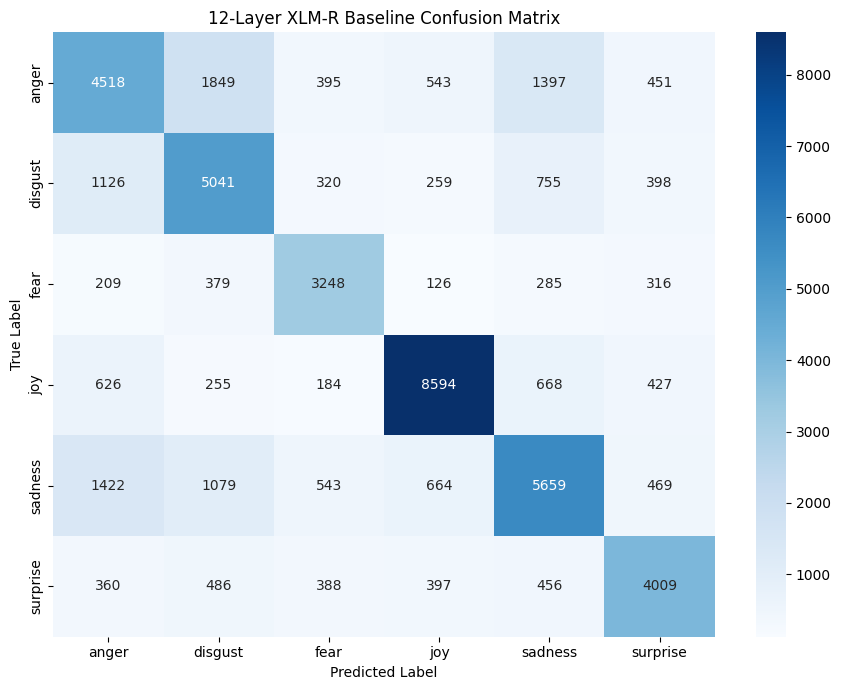

Executed cell #22


In [22]:
# ==========================================================
# CELL 22
# Plot one confusion matrix for the 12-layer baseline
# ==========================================================

print("Starting cell #22")

cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])

print("Confusion matrix total count:", int(cm.sum()))
print("This total equals the number of flat test samples, not the number of original rows.")

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("12-Layer XLM-R Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

print("Executed cell #22")

In [23]:
# ==========================================================
# CELL 23
# Print final baseline model information
# ==========================================================

print("Starting cell #23")

base_baseline = get_base_model(baseline_model)

total_params = sum(p.numel() for p in base_baseline.parameters())
trainable_params = sum(p.numel() for p in base_baseline.parameters() if p.requires_grad)

model_only_bytes = 0
for tensor in base_baseline.state_dict().values():
    model_only_bytes += tensor.numel() * tensor.element_size()
model_only_size_mb = model_only_bytes / (1024 ** 2)

saved_model_only_size_mb = None
saved_full_checkpoint_size_mb = None

if os.path.exists(baseline_model_only_path):
    saved_model_only_size_mb = os.path.getsize(baseline_model_only_path) / (1024 ** 2)

if os.path.exists(baseline_full_checkpoint_path):
    saved_full_checkpoint_size_mb = os.path.getsize(baseline_full_checkpoint_path) / (1024 ** 2)

print("\n================ BASELINE MODEL INFO ================")
print("Model:", BASELINE_MODEL_NAME)
print("Architecture: full 12-layer XLM-RoBERTa-base classifier")
print("Training loss: CE + row alignment + supervised contrastive loss")
print("Knowledge distillation: No")
print("Student compression: No")
print("Model-only checkpoint:", baseline_model_only_path)
print("Full training checkpoint:", baseline_full_checkpoint_path)
print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")
print(f"Model-only inference size estimate from tensors: {model_only_size_mb:.2f} MB")
if saved_model_only_size_mb is not None:
    print(f"Saved model-only checkpoint size: {saved_model_only_size_mb:.2f} MB")
if saved_full_checkpoint_size_mb is not None:
    print(f"Saved full training checkpoint size: {saved_full_checkpoint_size_mb:.2f} MB")
print("\nImportant reporting note:")
print("- Model-only size is the real deployable/inference model size.")
print("- Full checkpoint size includes optimizer, scheduler, and AMP scaler states, so it is much larger and can be around 3GB.")
print("=====================================================")

print("Executed cell #23")

Starting cell #23

================ BASELINE MODEL INFO ================
Model: xlm-roberta-base
Architecture: full 12-layer XLM-RoBERTa-base classifier
Training loss: CE + row alignment + supervised contrastive loss
Knowledge distillation: No
Student compression: No
Model-only checkpoint: /kaggle/working/baseline_12layer_xlmr_fast_training/best_baseline_12layer_model_only.pt
Full training checkpoint: /kaggle/working/baseline_12layer_xlmr_fast_training/baseline_12layer_full_training_checkpoint.pt
Total parameters: 277,457,670
Trainable parameters: 277,457,670
Model-only inference size estimate from tensors: 1058.42 MB
Saved model-only checkpoint size: 1058.50 MB
Saved full training checkpoint size: 3175.52 MB

Important reporting note:
- Model-only size is the real deployable/inference model size.
- Full checkpoint size includes optimizer, scheduler, and AMP scaler states, so it is much larger and can be around 3GB.
Executed cell #23
